## Treinando o Modelo

In [1]:
#Importações

import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

from sklearn.compose import ColumnTransformer
from sklearn.dummy import DummyRegressor
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import (OrdinalEncoder, OneHotEncoder, PolynomialFeatures, PowerTransformer, RobustScaler, StandardScaler,
QuantileTransformer)

from joblib import dump

from apoio.config import DADOS_LIMPOS, MODELO_FINAL
from apoio.auxiliares import dataframe_coeficientes
from apoio.graficos import (plot_coeficientes, plot_comparar_metricas_modelos, plot_residuos_estimador)
from apoio.modelos import (organiza_resultados, treinar_e_validar_modelo_regressao, grid_search_cv_regressor)

import warnings
warnings.filterwarnings("ignore")

#### Checagens básicas da base

In [2]:
df = pd.read_parquet(DADOS_LIMPOS)
df.head()

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity,median_income_cat,rooms_per_household,population_per_household,bedrooms_per_room
0,-122.23,37.88,41,880,129,322,126,8.3252,452600,NEAR BAY,5,6.984127,2.555556,0.146591
1,-122.22,37.86,21,7099,1106,2401,1138,8.3014,358500,NEAR BAY,5,6.238137,2.109842,0.155797
2,-122.26,37.84,42,2555,665,1206,595,2.0804,226700,NEAR BAY,2,4.294118,2.026891,0.260274
3,-122.26,37.85,50,1120,283,697,264,2.1250,140000,NEAR BAY,2,4.242424,2.640152,0.252679
4,-122.26,37.84,50,2239,455,990,419,1.9911,158700,NEAR BAY,2,5.343675,2.362768,0.203216


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 17564 entries, 0 to 17563
Data columns (total 14 columns):
 #   Column                    Non-Null Count  Dtype   
---  ------                    --------------  -----   
 0   longitude                 17564 non-null  float64 
 1   latitude                  17564 non-null  float64 
 2   housing_median_age        17564 non-null  int8    
 3   total_rooms               17564 non-null  int16   
 4   total_bedrooms            17564 non-null  int16   
 5   population                17564 non-null  int16   
 6   households                17564 non-null  int16   
 7   median_income             17564 non-null  float64 
 8   median_house_value        17564 non-null  int32   
 9   ocean_proximity           17564 non-null  category
 10  median_income_cat         17564 non-null  int64   
 11  rooms_per_household       17564 non-null  float64 
 12  population_per_household  17564 non-null  float64 
 13  bedrooms_per_room         17564 non-null  floa

#### Definindo:

- Target (coluna alvo)
- Coluna do one hot encoder
- Coluna do ordinal encoder
- Colunas do robust scaler

#### Como saber quais colunas se aplicam?

- **One Hot Encoder:** usado quando os valores não têm hierarquia.
- **OrdinalEncoder:** usado quando existe hierarquia clara.
- **RobustScaler:** usado em variáveis numéricas, principalmente quando tem valores extremos (outliers).

In [4]:
coluna_target = ["median_house_value"]
coluna_one_hot_encoder = ["ocean_proximity"]
coluna_ordinal_encoder = ["median_income_cat"]

In [5]:
colunas_robust_scaler = df.columns.difference(coluna_target + coluna_one_hot_encoder + coluna_ordinal_encoder)
colunas_robust_scaler

Index(['bedrooms_per_room', 'households', 'housing_median_age', 'latitude',
       'longitude', 'median_income', 'population', 'population_per_household',
       'rooms_per_household', 'total_bedrooms', 'total_rooms'],
      dtype='object')

#### Aplicando RobustScaler e PolynomialFeatures nas colunas numéricas

In [6]:
pipeline_robust_scaler = Pipeline(steps=[("robust_scaler", RobustScaler()), ("poly", PolynomialFeatures(degree=1, include_bias=False))])

**RobustScaler** vai normalizar os dados usando mediana e IQR (Intervalo Interquartil), diminuir o impacto de outliers.

**PolynomialFeatures** retorna as mesmas colunas.

#### Criando um pipeline que aplica transformações diferentes em colunas diferentes

In [7]:
preprocessamento = ColumnTransformer(transformers=[("ordinal_encoder", OrdinalEncoder(categories="auto"), coluna_ordinal_encoder),
                                                   ("one_hot", OneHotEncoder(drop="first"), coluna_one_hot_encoder),
                                                   ("robust_scaler_poly", pipeline_robust_scaler, colunas_robust_scaler)])

**OrdinalEncoder** transforma categorias com ordem em números.

**OneHotEncoder** cria colunas binárias (0 ou 1).

#### Definindo X e y para serem usados posteriormente

In [8]:
X = df.drop(columns=coluna_target)
y = df[coluna_target]

In [9]:
X.head()

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,ocean_proximity,median_income_cat,rooms_per_household,population_per_household,bedrooms_per_room
0,-122.23,37.88,41,880,129,322,126,8.3252,NEAR BAY,5,6.984127,2.555556,0.146591
1,-122.22,37.86,21,7099,1106,2401,1138,8.3014,NEAR BAY,5,6.238137,2.109842,0.155797
2,-122.26,37.84,42,2555,665,1206,595,2.0804,NEAR BAY,2,4.294118,2.026891,0.260274
3,-122.26,37.85,50,1120,283,697,264,2.1250,NEAR BAY,2,4.242424,2.640152,0.252679
4,-122.26,37.84,50,2239,455,990,419,1.9911,NEAR BAY,2,5.343675,2.362768,0.203216


In [10]:
y.head()

,median_house_value
0,452600
1,358500
2,226700
3,140000
4,158700


#### Criando o conjunto de hiperparâmetros que o GridSearch vai testar automaticamente

In [11]:
param_grid = {
    "regressor__preprocessor__robust_scaler_poly__poly__degree": [1, 2, 3],
    "regressor__reg__alpha": [1E-2, 5E-2, 0.1, 0.25, 0.5, 1.0, 2.0, 5.0, 10.0, 20.0, 50.0],
}

#### Criando o GridSearch

In [12]:
grid_search = grid_search_cv_regressor(regressor=Ridge(), param_grid=param_grid, preprocessor=preprocessamento,
                                       target_transformer=QuantileTransformer(output_distribution="normal"))

grid_search

GridSearchCV(cv=KFold(n_splits=5, random_state=42, shuffle=True),
             estimator=TransformedTargetRegressor(regressor=Pipeline(steps=[('preprocessor',
                                                                             ColumnTransformer(transformers=[('ordinal_encoder',
                                                                                                              OrdinalEncoder(),
                                                                                                              ['median_income_cat']),
                                                                                                             ('one_hot',
                                                                                                              OneHotEncoder(drop='first'),
                                                                                                              ['ocean_proximity']),
                                                                                                             ('robust_scaler_poly',
                                                                                                              Pipeline(steps=[('robust_scaler',
                                                                                                                               Ro...
                                                                             Ridge())]),
                                                  transformer=QuantileTransformer(output_distribution='normal')),
             n_jobs=-1,
             param_grid={'regressor__preprocessor__robust_scaler_poly__poly__degree': [1,
                                                                                       2,
                                                                                       3],
                         'regressor__reg__alpha': [0.01, 0.05, 0.1, 0.25, 0.5,
                                                   1.0, 2.0, 5.0, 10.0, 20.0,
                                                   50.0]},
             refit='neg_root_mean_squared_error',
             scoring=['r2', 'neg_mean_absolute_error',
                      'neg_root_mean_squared_error'],
             verbose=1)

O que o **GridSearch** faz?

Testa as combinações, avalia elas com validação cruzada e escolhe a melhor

In [13]:
grid_search.fit(X, y)

Fitting 5 folds for each of 33 candidates, totalling 165 fits


GridSearchCV(cv=KFold(n_splits=5, random_state=42, shuffle=True),
             estimator=TransformedTargetRegressor(regressor=Pipeline(steps=[('preprocessor',
                                                                             ColumnTransformer(transformers=[('ordinal_encoder',
                                                                                                              OrdinalEncoder(),
                                                                                                              ['median_income_cat']),
                                                                                                             ('one_hot',
                                                                                                              OneHotEncoder(drop='first'),
                                                                                                              ['ocean_proximity']),
                                                                                                             ('robust_scaler_poly',
                                                                                                              Pipeline(steps=[('robust_scaler',
                                                                                                                               Ro...
                                                                             Ridge())]),
                                                  transformer=QuantileTransformer(output_distribution='normal')),
             n_jobs=-1,
             param_grid={'regressor__preprocessor__robust_scaler_poly__poly__degree': [1,
                                                                                       2,
                                                                                       3],
                         'regressor__reg__alpha': [0.01, 0.05, 0.1, 0.25, 0.5,
                                                   1.0, 2.0, 5.0, 10.0, 20.0,
                                                   50.0]},
             refit='neg_root_mean_squared_error',
             scoring=['r2', 'neg_mean_absolute_error',
                      'neg_root_mean_squared_error'],
             verbose=1)

O que o **.fit()** faz?

Treina o modelo que o GridSearch escolheu como melhor.

#### Checando os melhores parâmetros e o melhor score

In [14]:
grid_search.best_params_

{'regressor__preprocessor__robust_scaler_poly__poly__degree': 3,
 'regressor__reg__alpha': 20.0}

In [15]:
grid_search.best_score_

np.float64(-50451.96905393158)

#### Criando um DataFrame com os coeficientes do melhor modelo

In [16]:
coeficientes = dataframe_coeficientes(grid_search.best_estimator_.regressor_["reg"].coef_,
                                      grid_search.best_estimator_.regressor_["preprocessor"].get_feature_names_out())

coeficientes

,coeficiente
robust_scaler_poly__longitude,-0.881540
robust_scaler_poly__latitude,-0.783543
one_hot__ocean_proximity_INLAND,-0.491287
robust_scaler_poly__population_per_household,-0.334950
robust_scaler_poly__latitude^2,-0.291169
...,...
robust_scaler_poly__housing_median_age longitude^2,0.191535
robust_scaler_poly__latitude median_income population_per_household,0.221659
robust_scaler_poly__housing_median_age median_income,0.249547
robust_scaler_poly__bedrooms_per_room,0.319652


#### Gráfico dos coeficientes

Existe uma quantidade de coeficientes muito grande, então faremos um filtro de coefientes no intervalo de -0.2 e 0.2, que são diferentes de 0.

In [17]:
coeficientes[coeficientes["coeficiente"].between(-0.2, 0.2) & coeficientes["coeficiente"]!=0]

,coeficiente
robust_scaler_poly__longitude^3,-0.198829
one_hot__ocean_proximity_NEAR BAY,-0.196309
robust_scaler_poly__longitude^2 rooms_per_household,-0.175897
robust_scaler_poly__housing_median_age median_income population_per_household,-0.172164
robust_scaler_poly__latitude^2 population,-0.170635
...,...
robust_scaler_poly__bedrooms_per_room housing_median_age total_rooms,0.170925
robust_scaler_poly__bedrooms_per_room median_income,0.179319
robust_scaler_poly__latitude^2 longitude,0.184749
robust_scaler_poly__longitude median_income population_per_household,0.190066


A quantidade de coeficientes ainda é muito grande, então o gráfico será feito com os coeficientes que não entram no filtro anterior.

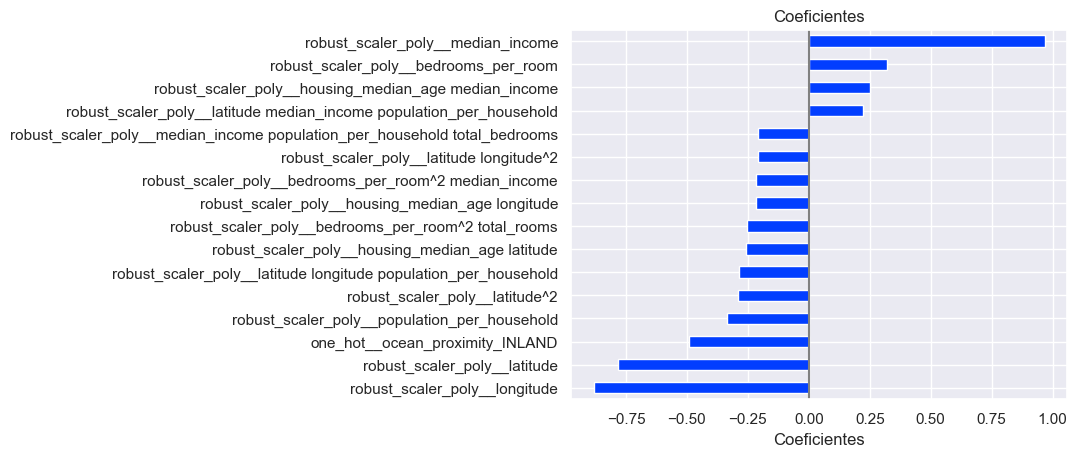

In [18]:
plot_coeficientes(coeficientes[~coeficientes["coeficiente"].between(-0.2, 0.2)])

Crie um dicionário chamado regressors, que recebe como chaves 4 dicionários, cada um sendo DummyRegressor, LinearRegression, LinearRegression_target e Ridge_grid_search. Esses ddicioários devem ter como chaves: preprocessor, regressor e target_transformer.

#### Criando um novo DataFrame com o resultado de treino de alguns modelos

In [19]:
regressors = {
    "DummyRegressor": {
        "preprocessor": None,
        "regressor": DummyRegressor(strategy="mean"),
        "target_transformer": None
    },
    "LinearRegression": {
        "preprocessor": preprocessamento,
        "regressor": LinearRegression(),
        "target_transformer": None
    },
    "LinearRegression_target": {
        "preprocessor": preprocessamento,
        "regressor": LinearRegression(),
        "target_transformer": QuantileTransformer(output_distribution="normal")
    },
    "Ridge_grid_search": {
        "preprocessor": grid_search.best_estimator_.regressor_["preprocessor"],
        "regressor": grid_search.best_estimator_.regressor_["reg"],
        "target_transformer": grid_search.best_estimator_.transformer_
    }
}

resultados = {
    nome_modelo: treinar_e_validar_modelo_regressao(X, y, **regressor)
    for nome_modelo, regressor in regressors.items()
}

df_resultados = organiza_resultados(resultados)

df_resultados

,model,fit_time,score_time,test_r2,test_neg_mean_absolute_error,test_neg_root_mean_squared_error,time_seconds
0,DummyRegressor,0.006095,0.004,-0.000081,-77516.042766,-96239.705692,0.010095
1,DummyRegressor,0.004512,0.006652,-0.000146,-75787.787194,-95217.629397,0.011163
2,DummyRegressor,0.003097,0.004999,-0.001737,-76753.598961,-96253.253947,0.008096
3,DummyRegressor,0.004002,0.005004,-0.000101,-76837.804811,-95983.885799,0.009005
4,DummyRegressor,0.004,0.006,-0.000114,-76617.245449,-96182.764729,0.01
5,LinearRegression,0.085152,0.020177,0.682162,-39855.691222,-54254.958862,0.105329
6,LinearRegression,0.058609,0.019002,0.66999,-40272.5658,-54695.230987,0.077611
7,LinearRegression,0.054504,0.020153,0.649247,-42178.059695,-56955.987903,0.074657
8,LinearRegression,0.047442,0.018161,0.669873,-40806.492334,-55146.319086,0.065603
9,LinearRegression,0.055552,0.017328,0.669023,-40788.497206,-55331.350878,0.072881


#### Agrupando resultados por modelo, calculando a média das métricas, ordena pelo erro e identificando o melhor modelo

In [20]:
df_resultados.groupby("model").mean().sort_values(by="test_neg_root_mean_squared_error")

,fit_time,score_time,test_r2,test_neg_mean_absolute_error,test_neg_root_mean_squared_error,time_seconds
model,,,,,,
DummyRegressor,0.004341,0.005331,-0.000436,-76702.495836,-95975.447913,0.009672
LinearRegression,0.060252,0.018964,0.668059,-40780.261251,-55276.769543,0.079216
LinearRegression_target,0.065612,0.019899,0.678102,-38675.937704,-54429.950173,0.085512
Ridge_grid_search,0.264095,0.0459,0.723266,-35373.242378,-50459.60985,0.309995


#### Gráficos comparando os modelos de regressão

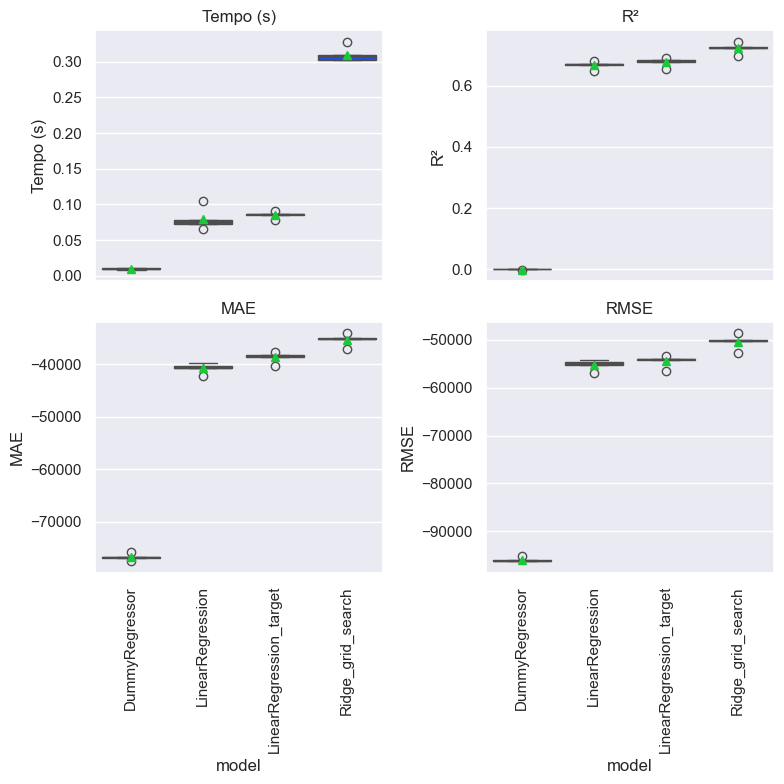

In [21]:
plot_comparar_metricas_modelos(df_resultados)

#### O que esses gráficos estão te dizendo?

🥇 Melhor modelo: **Ridge_grid_search**
- Melhor R²
- Menor erro (MAE e RMSE)

🥈 Segundo lugar: **LinearRegression_target**
- Melhor que o linear normal
- Transformar o target ajudou um pouco

🥉 Terceiro: **LinearRegression**
- Já é bom
- Mas perde pro Ridge

🚫 Pior: **DummyRegressor**
- Serve só como referência
- Mostra que seus modelos realmente aprenderam algo

O modelo Ridge com otimização apresentou o melhor desempenho em todas as métricas, com aumento moderado no custo computacional. A transformação do target também contribuiu para melhoria em relação à regressão linear padrão.

#### Gráficos para ver se o modelo está bom, onde ele erra e se existe padrão no erro

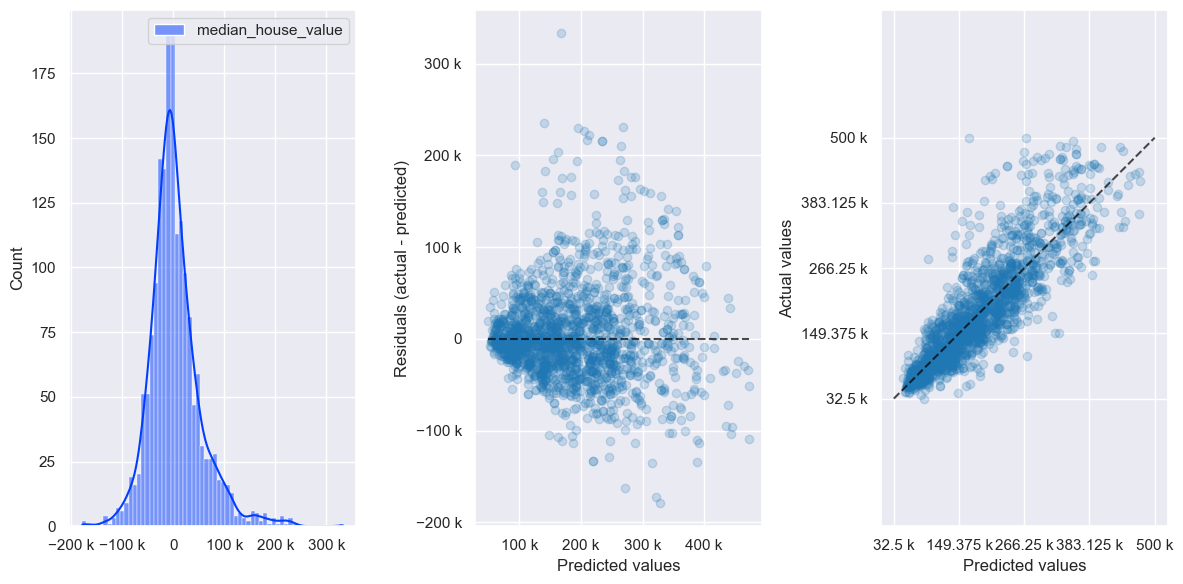

In [22]:
plot_residuos_estimador(grid_search.best_estimator_, X, y, fracao_amostra=0.1, eng_formatter=True)

O modelo apresenta bom ajuste global, porém evidencia heterocedasticidade e maior dispersão dos resíduos para valores altos, indicando dificuldade em modelar corretamente imóveis de maior valor.

**Heterocedasticidade** é um fenômeno estatístico em modelos de regressão, onde a variância dos erros (resíduos) não é constante ao longo das observações, violando a hipótese de homocedasticidade.

**Homoscedasticidade** é a suposição estatística, onde a variância dos resíduos (erros) é constante ao longo de todas as variáveis independentes, garantindo modelos de regressão confiáveis.

In [23]:
dump(grid_search.best_estimator_, MODELO_FINAL)

['C:\\Users\\prof_\\Ciencia_de_Dados_Exercicios\\Projetos\\ProjetoML\\dados\\ridge_polyfeat_target_quantile.joblib']